# <center>Project Title- Telcom Customer Churn Analysis</center>

## Project Summary :

The Telcom Customer Churn Analysis project aims to predict whether customers will discontinue telecom services using machine learning techniques. By analyzing customer demographics, service usage, and billing information, the project identifies patterns that influence churn behavior. Predictive models will be developed to help telecom companies detect at-risk customers and implement strategies to improve retention.

## GitHub Link :

https://github.com/chetansgode/Telcom_Customer_Churn_Analysis.git

## Problem Statement :

Customer churn is a major challenge for telecom companies, as losing existing customers directly impacts revenue and business growth. Many customers discontinue telecom services due to factors such as high charges, poor service quality, or better offers from competitors. However, identifying which customers are likely to leave in advance is difficult using traditional analysis methods. The problem is to develop a machine learning model that can analyze customer demographic information, service usage patterns, and billing details to predict whether a customer is likely to churn. This predictive system can help telecom companies take proactive actions to retain customers and improve overall customer satisfaction.

## Import Libraries :

In [34]:
# for data processing
import numpy as np 
import pandas as pd 
# for visualisation of data 
import matplotlib.pyplot as plt 
import seaborn as sns 
#filter warnings
import warnings
warnings.filterwarnings('ignore')
#set max columns display in pandas 
pd.set_option("display.max_columns", 40)
#to preprocessing data
from sklearn.preprocessing import PowerTransformer,OneHotEncoder,LabelEncoder  #OneHotEncoder>Multicategory,LabelEncoder>binary,map():know variable
#to balance class imbalance 
from imblearn.over_sampling import SMOTE
#for features selection 
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Loading Dataset : 

In [2]:
#loading data
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Variables Description:

customerID :	Unique ID assigned to each customer

gender :	Customer's gender (Male/Female)

SeniorCitizen :	Indicates if the customer is a senior citizen (1 = Yes, 0 = No)

Partner :	Whether the customer has a partner (Yes/No)

Dependents :	Whether the customer has dependents (Yes/No)

tenure :	Number of months the customer has stayed with the company

PhoneService :	Whether the customer has phone service (Yes/No)

MultipleLines :	Whether the customer has multiple phone lines (Yes/No/No phone service)

InternetService :	Type of internet service (DSL, Fiber optic, No)

OnlineSecurity :	Whether the customer has online security service

OnlineBackup :	Whether the customer has online backup

DeviceProtection :	Whether the customer has device protection

TechSupport	: Whether the customer has technical support

StreamingTV : 	Whether the customer has TV streaming service

StreamingMovies :	Whether the customer has movie streaming service

Contract :	Type of contract (Month-to-month, One year, Two year)

PaperlessBilling :	Whether the customer uses paperless billing (Yes/No)

PaymentMethod :	Customer payment method (Credit card, Bank transfer, Electronic check, Mailed check)

MonthlyCharges :	Amount charged to the customer every month

TotalCharges :	Total amount charged to the customer

Churn :	Indicates if the customer left the company (Yes = Churn, No = Stayed)

## Dataset First View :

In [3]:
#checking data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Dataset Shape :

In [4]:
print(F"Shape of available data : {df.shape}") 
print(f"No of features in data : {df.shape[1]}\nNo of records in data : {df.shape[0]}")

Shape of available data : (7043, 21)
No of features in data : 21
No of records in data : 7043


#### Dataset Duplicate check :

In [5]:
print(f"Checking duplicate record in dataset : {df.duplicated().sum()}")

Checking duplicate record in dataset : 0


#### Checking Null values in datasets :

In [6]:
print('Checking total null value in each feature :\n')
print(pd.DataFrame(df.isna().sum(),columns=[['Sum of Null values']]))

Checking total null value in each feature :

                 Sum of Null values
customerID                        0
gender                            0
SeniorCitizen                     0
Partner                           0
Dependents                        0
tenure                            0
PhoneService                      0
MultipleLines                     0
InternetService                   0
OnlineSecurity                    0
OnlineBackup                      0
DeviceProtection                  0
TechSupport                       0
StreamingTV                       0
StreamingMovies                   0
Contract                          0
PaperlessBilling                  0
PaymentMethod                     0
MonthlyCharges                    0
TotalCharges                      0
Churn                             0


#### Checking data types :

In [7]:
print('Checking data types of each features :\n')
df.info()

Checking data types of each features :

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBill

#### Data Cleaning :

In [8]:
#Changing data type of TotalCharges  
print(f"data types of TotalCharges is : {df['TotalCharges'].dtypes}\n")

print('Some record has no data  :\n')
print(df[df['TotalCharges'].str.isspace()][['customerID','TotalCharges']])

#checking data distribution without space data 

print(f"\nData distribution by ignoring space record :\n{df[~df['TotalCharges'].str.isspace()]['TotalCharges'].astype('float').describe()}")

#Convert data type from string str to float

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#don't use median because all data has tenure=0 so select recent monthly charge 
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])    


data types of TotalCharges is : str

Some record has no data  :

      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             
6754  2775-SEFEE             

Data distribution by ignoring space record :
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


#### Checking MonthlyCharges has outlier or not (iqr):

Upper and Lower range for Outlier is : 171.38,-46.02 and our data max: 118.75 and min: 18.25 record value within range so no outlier present


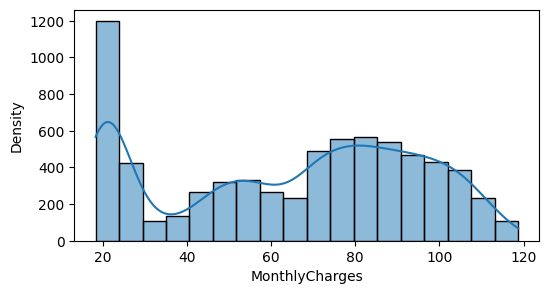

In [9]:
#checking outlier in data or not  bu iqr (Q3-Q1)
iqr=(df['MonthlyCharges'].quantile(0.75) -df['MonthlyCharges'].quantile(0.25))*1.5
upper_layer=round(df['MonthlyCharges'].quantile(0.75)+iqr,2)
lower_layer=round(df['MonthlyCharges'].quantile(0.25)-iqr,2)
print(f"Upper and Lower range for Outlier is : {upper_layer},{lower_layer} and \
our data max: {df['MonthlyCharges'].max()} and min: {df['MonthlyCharges'].min()} \
record value within range so no outlier present")

#data distribution
plt.figure(figsize=(6,3))
sns.histplot(df['MonthlyCharges'],kde=True)
plt.xlabel('MonthlyCharges')
plt.ylabel('Density') 
plt.show()


## EDA

#### 1) Analyse how many customer has left the service by gender ?

In [10]:
# Analysis how many churn gender wise 
data_genderwise_churn=df.groupby(['gender','Churn']).size().reset_index().rename(columns={0 :'total_count'}).set_index('gender')
print(data_genderwise_churn)
#check average total churn gender wise
churn_counts = data_genderwise_churn.reset_index().groupby('Churn')['total_count'].sum()
#check female wise churn
female_df = data_genderwise_churn.reset_index().iloc[:2]
#check male wise churn
male_df = data_genderwise_churn.reset_index().iloc[2:]

       Churn  total_count
gender                   
Female    No         2549
Female   Yes          939
Male      No         2625
Male     Yes          930


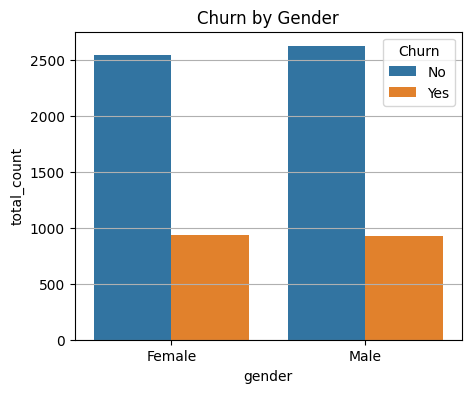

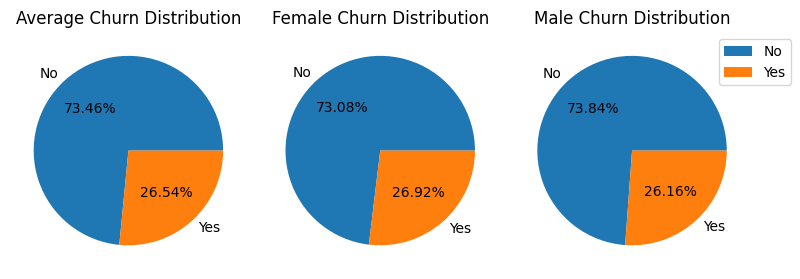

In [11]:
#bar plot for customer churn 
plt.figure(figsize=(5,4))
sns.barplot(data=data_genderwise_churn, x='gender', y='total_count', hue='Churn')
plt.title("Churn by Gender")
plt.grid(visible= True,axis='y')
plt.show()


plt.figure(figsize=(8,3))
plt.subplot(1,3,1)
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.2f%%')
plt.title("Average Churn Distribution")

plt.subplot(1,3,2)
plt.title("Female Churn Distribution")
plt.pie(
    female_df['total_count'],
    labels=female_df['Churn'],
    autopct='%1.2f%%'
)

plt.subplot(1,3,3)
plt.title("Male Churn Distribution")
plt.pie(
    male_df['total_count'],
    labels=male_df['Churn'],
    autopct='%1.2f%%'
)

plt.legend(loc='upper right',bbox_to_anchor=(1.2,1))
plt.tight_layout()
plt.show()

##### Insight>>>


In [12]:
print('Insight :\n')
print(f"Total active user  Male is higher than Female by {data_genderwise_churn.reset_index().iloc[2,2]-data_genderwise_churn.reset_index().iloc[0,2]}\n")
print(f"Churn is Famale is higher than male by {round(26.92-26.16,2)}%")

Insight :

Total active user  Male is higher than Female by 76

Churn is Famale is higher than male by 0.76%


#### 2) Analyse how many customer has left the service by SeniorCitizen,Partner and PaperlessBilling ?


SeniorCitizen

Churn data categories by subcategories of  SeniorCitizen :

              Churn  total_count
SeniorCitizen                   
0                No         4508
0               Yes         1393
1                No          666
1               Yes          476

Churn data categories by SeniorCitizen except subcategory 0 & 1 :

Churn
No     5174
Yes    1869
Name: total_count, dtype: int64

Churn data category by selecting 0 one of subcategory of SeniorCitizen :

   SeniorCitizen Churn  total_count
0              0    No         4508
1              0   Yes         1393

Churn data category by selecting 1 one of subcategory of SeniorCitizen :

   SeniorCitizen Churn  total_count
2              1    No          666
3              1   Yes          476


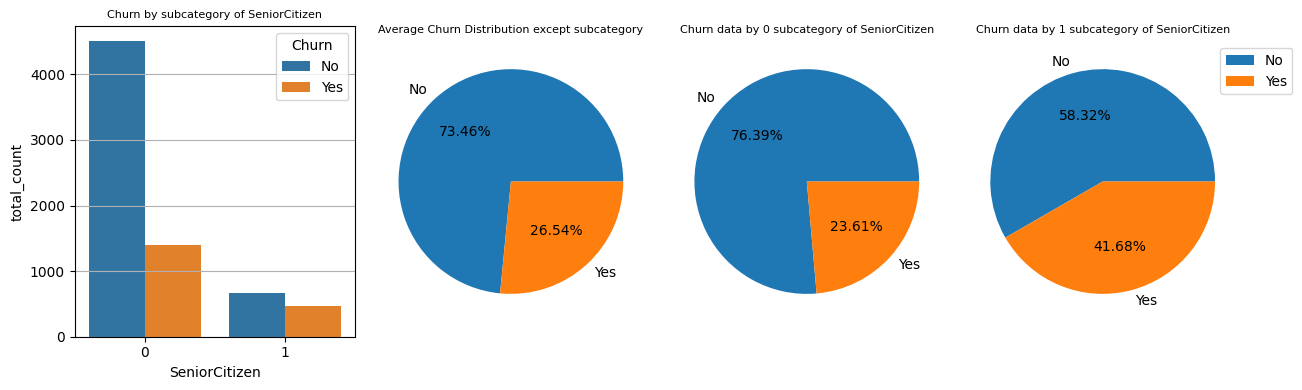

------------------------------------------------------------------------------------------------------------------------------------------------------

Partner

Churn data categories by subcategories of  Partner :

        Churn  total_count
Partner                   
No         No         2441
No        Yes         1200
Yes        No         2733
Yes       Yes          669

Churn data categories by Partner except subcategory No & Yes :

Churn
No     5174
Yes    1869
Name: total_count, dtype: int64

Churn data category by selecting No one of subcategory of Partner :

  Partner Churn  total_count
0      No    No         2441
1      No   Yes         1200

Churn data category by selecting Yes one of subcategory of Partner :

  Partner Churn  total_count
2     Yes    No         2733
3     Yes   Yes          669


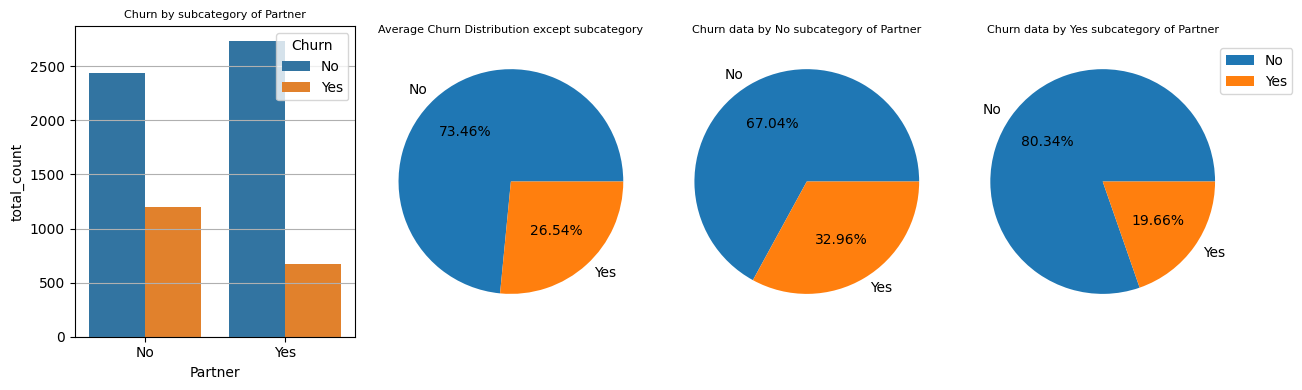

------------------------------------------------------------------------------------------------------------------------------------------------------

PaperlessBilling

Churn data categories by subcategories of  PaperlessBilling :

                 Churn  total_count
PaperlessBilling                   
No                  No         2403
No                 Yes          469
Yes                 No         2771
Yes                Yes         1400

Churn data categories by PaperlessBilling except subcategory No & Yes :

Churn
No     5174
Yes    1869
Name: total_count, dtype: int64

Churn data category by selecting No one of subcategory of PaperlessBilling :

  PaperlessBilling Churn  total_count
0               No    No         2403
1               No   Yes          469

Churn data category by selecting Yes one of subcategory of PaperlessBilling :

  PaperlessBilling Churn  total_count
2              Yes    No         2771
3              Yes   Yes         1400


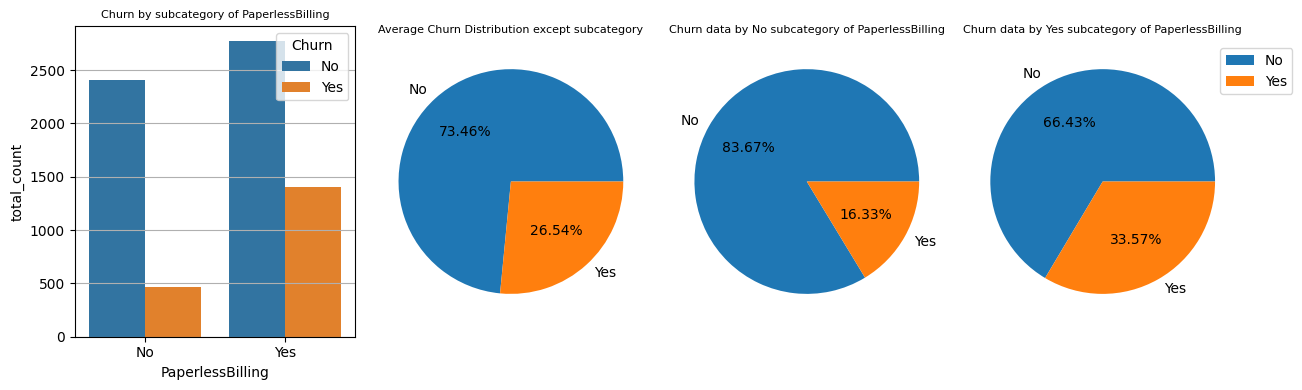

------------------------------------------------------------------------------------------------------------------------------------------------------


In [13]:
for i in ['SeniorCitizen','Partner','PaperlessBilling']:
    print(f"\n{i}\n")
    # Analysis how many churn 
    df1=df.groupby([i,'Churn']).size().reset_index().rename(columns={0 :'total_count'}).set_index(i)
    print(f'Churn data categories by subcategories of  {i} :\n')
    print(df1)
    
    #churn data categories by {i} except subcategory
    df2 = df1.reset_index().groupby('Churn')['total_count'].sum()
    #check sub category churn distribution
    df3 = df1.reset_index().iloc[:2]
    #check sub category churn distribution
    df4 = df1.reset_index().iloc[2:] 

    print(f'\nChurn data categories by {i} except subcategory {df3[i].iloc[0]} & {df4[i].iloc[0]} :\n')
    print(df2)
    print(f'\nChurn data category by selecting {df3[i].iloc[0]} one of subcategory of {i} :\n')
    print(df3)
    print(f'\nChurn data category by selecting {df4[i].iloc[0]} one of subcategory of {i} :\n')
    print(df4)

    plt.figure(figsize=(13,4))
    
    #bar plot for customer churn
    plt.subplot(1,4,1)
    sns.barplot(data=df1, x=i, y='total_count', hue='Churn')
    plt.title(f"Churn by subcategory of {i}",fontsize=8)
    plt.grid(visible= True,axis='y')



    plt.subplot(1,4,2)
    plt.pie(df2, labels=churn_counts.index, autopct='%1.2f%%')
    plt.title(f"Average Churn Distribution except subcategory",fontsize=8)
    
    plt.subplot(1,4,3)
    plt.title(f"Churn data by {df3[i].iloc[0]} subcategory of {i}",fontsize=8)
    plt.pie(
        df3['total_count'],
        labels=df3['Churn'],
        autopct='%1.2f%%'
    )
    
    plt.subplot(1,4,4)
    plt.title(f"Churn data by {df4[i].iloc[0]} subcategory of {i}",fontsize=8)
    plt.pie(
        df4['total_count'],
        labels=df4['Churn'],
        autopct='%1.2f%%'
    )
    
    plt.legend(loc='upper right',bbox_to_anchor=(1.2,1))
    plt.tight_layout()
    plt.show()

    print("-"*150)
    

##### Insight>>>

In [14]:
print('Insight :\n')
print('For SeniorCitizen')
print("Totat churn by SeniorCitizen is 26.54 %")
print("Total churn by No Subcategory of SeniorCitizen is 23.61 %")
print("Total churn by Yes subcategory of SeniorCitizen is 41.68 % and which is higher than no subcategory by 18.07 %")
print('\nFor Partner')
print("Totat churn by Partner is 26.54 %")
print("Total churn by No Subcategory of Partner is 32.96 % and which is higher than no subcategory by 13.3 %")
print("Total churn by Yes subcategory of Partner is 19.66 % ")
print('\nFor PaperlessBilling ')
print("Totat churn by PaperlessBilling  is 26.54 %")
print("Total churn by No Subcategory of PaperlessBilling  is 16.33 % ")
print("Total churn by Yes subcategory of PaperlessBilling  is 33.57 % and which is higher than no subcategory by 17.24 %")

Insight :

For SeniorCitizen
Totat churn by SeniorCitizen is 26.54 %
Total churn by No Subcategory of SeniorCitizen is 23.61 %
Total churn by Yes subcategory of SeniorCitizen is 41.68 % and which is higher than no subcategory by 18.07 %

For Partner
Totat churn by Partner is 26.54 %
Total churn by No Subcategory of Partner is 32.96 % and which is higher than no subcategory by 13.3 %
Total churn by Yes subcategory of Partner is 19.66 % 

For PaperlessBilling 
Totat churn by PaperlessBilling  is 26.54 %
Total churn by No Subcategory of PaperlessBilling  is 16.33 % 
Total churn by Yes subcategory of PaperlessBilling  is 33.57 % and which is higher than no subcategory by 17.24 %


short tenure churn more
contract type affect churn
payment method has the highest churn
internet service type affect churn
tech support reduce churn
online security churn less
monthly charges churn more
TotalCharges and churn

#### 3) Analysis how customer churn is affected by Contract,InternetService,TechSupport and OnlineSecurity variable?


Contract :

checking total data distribution of Contract with category :

         Contract  total_count
0  Month-to-month         3875
1        One year         1473
2        Two year         1695
checking subcategory wise data distribution of features Contract :

         Contract Churn  total_count
0  Month-to-month    No         2220
1  Month-to-month   Yes         1655
2        One year    No         1307
3        One year   Yes          166
4        Two year    No         1647
5        Two year   Yes           48
selecting one of subcatagory Month-to-month wise data distributions of Contract :

         Contract Churn  total_count
0  Month-to-month    No         2220
1  Month-to-month   Yes         1655
selecting one of subcatagory One year wise data distributions of Contract :

   Contract Churn  total_count
2  One year    No         1307
3  One year   Yes          166
selecting one of subcatagory Two year wise data distributions of Contract :

   Contract Churn  total_count
4 

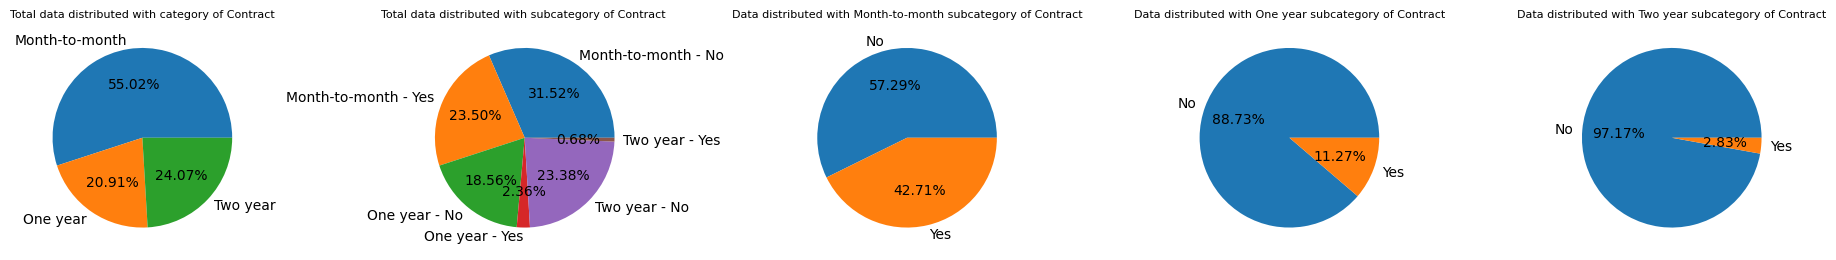

-----------------------------------------------------------------------------------------------------------------------------------------------------

InternetService :

checking total data distribution of InternetService with category :

  InternetService  total_count
0             DSL         2421
1     Fiber optic         3096
2              No         1526
checking subcategory wise data distribution of features InternetService :

  InternetService Churn  total_count
0             DSL    No         1962
1             DSL   Yes          459
2     Fiber optic    No         1799
3     Fiber optic   Yes         1297
4              No    No         1413
5              No   Yes          113
selecting one of subcatagory DSL wise data distributions of InternetService :

  InternetService Churn  total_count
0             DSL    No         1962
1             DSL   Yes          459
selecting one of subcatagory Fiber optic wise data distributions of InternetService :

  InternetService Churn  t

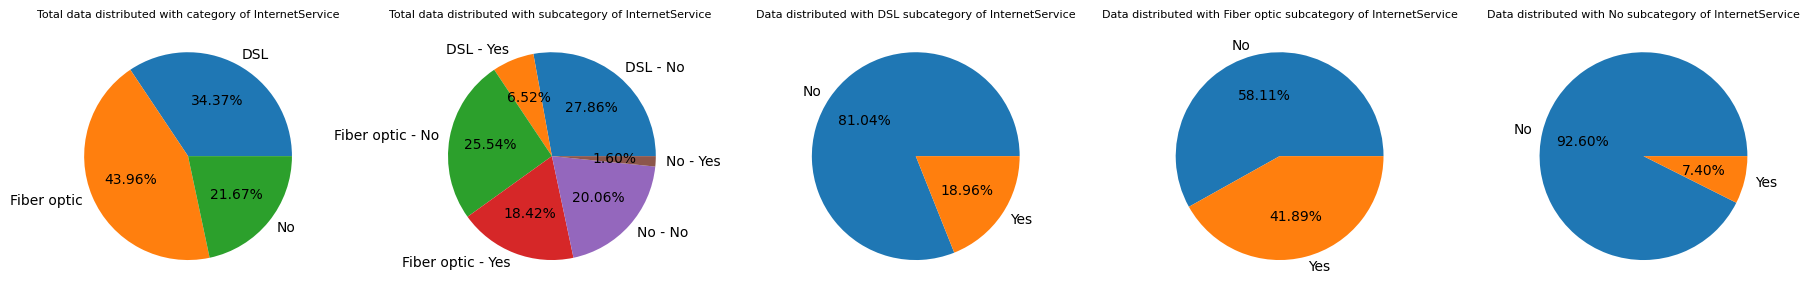

-----------------------------------------------------------------------------------------------------------------------------------------------------

TechSupport :

checking total data distribution of TechSupport with category :

           TechSupport  total_count
0                   No         3473
1  No internet service         1526
2                  Yes         2044
checking subcategory wise data distribution of features TechSupport :

           TechSupport Churn  total_count
0                   No    No         2027
1                   No   Yes         1446
2  No internet service    No         1413
3  No internet service   Yes          113
4                  Yes    No         1734
5                  Yes   Yes          310
selecting one of subcatagory No wise data distributions of TechSupport :

  TechSupport Churn  total_count
0          No    No         2027
1          No   Yes         1446
selecting one of subcatagory No internet service wise data distributions of TechSupport

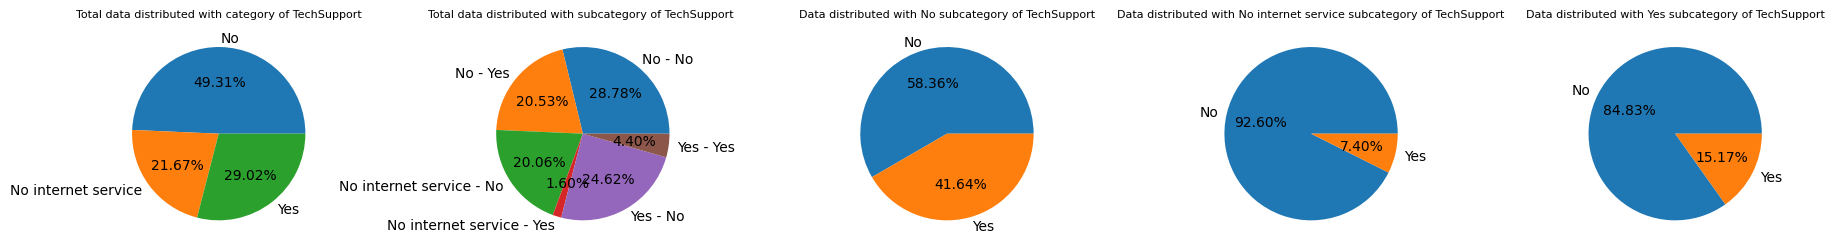

-----------------------------------------------------------------------------------------------------------------------------------------------------

OnlineSecurity :

checking total data distribution of OnlineSecurity with category :

        OnlineSecurity  total_count
0                   No         3498
1  No internet service         1526
2                  Yes         2019
checking subcategory wise data distribution of features OnlineSecurity :

        OnlineSecurity Churn  total_count
0                   No    No         2037
1                   No   Yes         1461
2  No internet service    No         1413
3  No internet service   Yes          113
4                  Yes    No         1724
5                  Yes   Yes          295
selecting one of subcatagory No wise data distributions of OnlineSecurity :

  OnlineSecurity Churn  total_count
0             No    No         2037
1             No   Yes         1461
selecting one of subcatagory No internet service wise data distrib

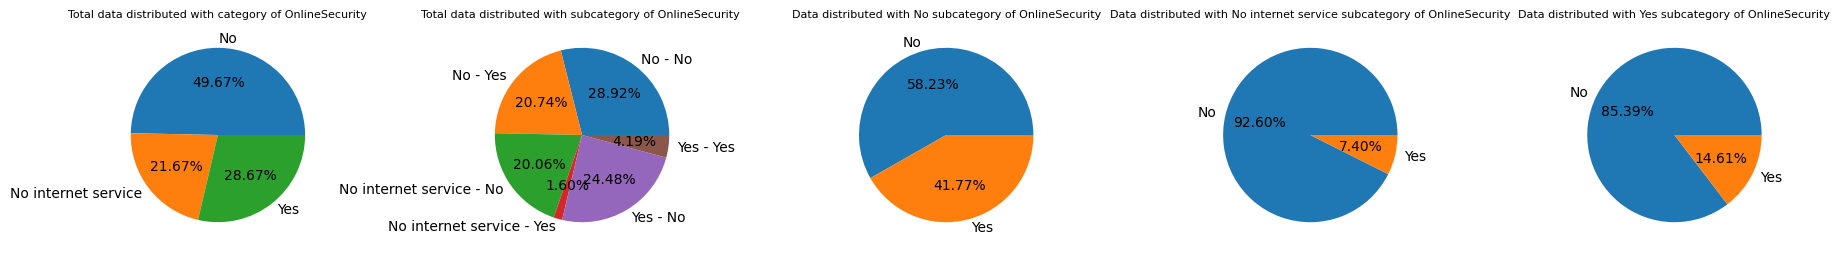

-----------------------------------------------------------------------------------------------------------------------------------------------------


In [15]:
#checking total data distribution with category
for i in ['Contract','InternetService','TechSupport','OnlineSecurity']:
    print(f"\n{i} :\n")
    df1=df.groupby(i)['Churn'].size().reset_index().rename(columns={'Churn':'total_count'})
    #checking subcategory wise data distribution of features
    df2=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})
    #selecting one of subcatagory wise data distributions
    df3=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})[:2]
    df4=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})[2:4]
    df5=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})[4:]
    print(f"checking total data distribution of {i} with category :\n")
    print(df1)
    print(f"checking subcategory wise data distribution of features {i} :\n")
    print(df2)
    print(f"selecting one of subcatagory { df3.iloc[0,0] } wise data distributions of {i} :\n")
    print(df3)
    print(f"selecting one of subcatagory { df4.iloc[0,0] } wise data distributions of {i} :\n")
    print(df4)
    print(f"selecting one of subcatagory { df5.iloc[0,0] } wise data distributions of {i} :\n")
    print(df5)

    plt.figure(figsize=(18,4))
    #category wise data distribute
    plt.subplot(1,5,1)
    plt.pie(df1['total_count'],labels=df1[i],autopct='%1.2f%%')
    plt.title(f'Total data distributed with category of {i}',fontsize=8)

    #plot subcategory wise data distribution
    plt.subplot(1,5,2)
    plt.pie(df2['total_count'],labels=df2[i] + " - " + df2['Churn'],autopct='%1.2f%%')
    plt.title(f"Total data distributed with subcategory of {i} ",fontsize=8)

    #plot one of subcategory data distribution
    plt.subplot(1,5,3)
    plt.pie(df3['total_count'],labels= df3['Churn'],autopct='%1.2f%%') 
    plt.title(f"Data distributed with { df3.iloc[0,0] } subcategory of {i}",fontsize=8)
    
    #plot one of subcategory data distribution
    plt.subplot(1,5,4)
    plt.pie(df4['total_count'],labels= df4['Churn'],autopct='%1.2f%%') 
    plt.title(f"Data distributed with { df4.iloc[0,0] } subcategory of {i}",fontsize=8) 

    #plot one of subcategory data distribution
    plt.subplot(1,5,5)
    plt.pie(df5['total_count'],labels= df5['Churn'],autopct='%1.2f%%') 
    plt.title(f"Data distributed with { df5.iloc[0,0] } subcategory of {i}",fontsize=8)
    plt.tight_layout()
   
    plt.show()
    print("-"*149)

##### Insight>>>

In [16]:
print("Insight :\n")
print('Contract :')
print("Totol data distributed with subcategories of 'Contract' variable has min percentage of 'One Year' and max percentage of 'Month-to-month'")
print("Max customer churn rate in 'Month to month' type and min in 'Two year' type of 'contract' ")
print('\nInternetService :')
print("Totol data distributed with subcategories of 'InternetService' variable has min percentage of 'No' and max percentage of 'Fiber optic'")
print("Max customer churn rate in 'Fiber optic' type and min in 'No' type of 'InternetService' ")
print('\nTechSupport :')
print("Totol data distributed with subcategories of 'TechSupport' variable has min percentage of 'No internet service' and max percentage of 'No'")
print("Max customer churn rate in 'No' type and min in 'No internet service' type of 'TechSupport' ")
print('\nOnlineSecurity :')
print("Totol data distributed with subcategories of 'OnlineSecurity' variable has min percentage of 'No internet service' and max percentage of 'No'")
print("Max customer churn rate in 'No' type and min in 'No internet service' type of 'OnlineSecurity' ")


Insight :

Contract :
Totol data distributed with subcategories of 'Contract' variable has min percentage of 'One Year' and max percentage of 'Month-to-month'
Max customer churn rate in 'Month to month' type and min in 'Two year' type of 'contract' 

InternetService :
Totol data distributed with subcategories of 'InternetService' variable has min percentage of 'No' and max percentage of 'Fiber optic'
Max customer churn rate in 'Fiber optic' type and min in 'No' type of 'InternetService' 

TechSupport :
Totol data distributed with subcategories of 'TechSupport' variable has min percentage of 'No internet service' and max percentage of 'No'
Max customer churn rate in 'No' type and min in 'No internet service' type of 'TechSupport' 

OnlineSecurity :
Totol data distributed with subcategories of 'OnlineSecurity' variable has min percentage of 'No internet service' and max percentage of 'No'
Max customer churn rate in 'No' type and min in 'No internet service' type of 'OnlineSecurity' 


#### 4) Analysis how customer churn is affected by PaymentMethod

In [17]:
#checking data churn distribution of PaymentMethod variable
df1=df.groupby('PaymentMethod')['Churn'].size().reset_index().rename(columns={'Churn':'total_count'})
#checking subcategory wise data distribution of features
df2=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})
#selecting one of subcatagory wise data distributions
df3=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[:2]
df4=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[2:4]
df5=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[4:6]
df6=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[6:]
print(f"\nChecking total data distribution of PaymentMethod with category :")
print(df1)
print(f"\nChecking subcategory wise data distribution of features PaymentMethod :")
print(df2)
print(f"\nSelecting one of subcatagory { df3.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df3)
print(f"\nSelecting one of subcatagory { df4.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df4)
print(f"\nSelecting one of subcatagory { df5.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df5)
print(f"\nSelecting one of subcatagory { df6.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df6)





Checking total data distribution of PaymentMethod with category :
               PaymentMethod  total_count
0  Bank transfer (automatic)         1544
1    Credit card (automatic)         1522
2           Electronic check         2365
3               Mailed check         1612

Checking subcategory wise data distribution of features PaymentMethod :
               PaymentMethod Churn  total_count
0  Bank transfer (automatic)    No         1286
1  Bank transfer (automatic)   Yes          258
2    Credit card (automatic)    No         1290
3    Credit card (automatic)   Yes          232
4           Electronic check    No         1294
5           Electronic check   Yes         1071
6               Mailed check    No         1304
7               Mailed check   Yes          308

Selecting one of subcatagory Bank transfer (automatic) wise data distributions of PaymentMethod :
               PaymentMethod Churn  total_count
0  Bank transfer (automatic)    No         1286
1  Bank transfer (autom

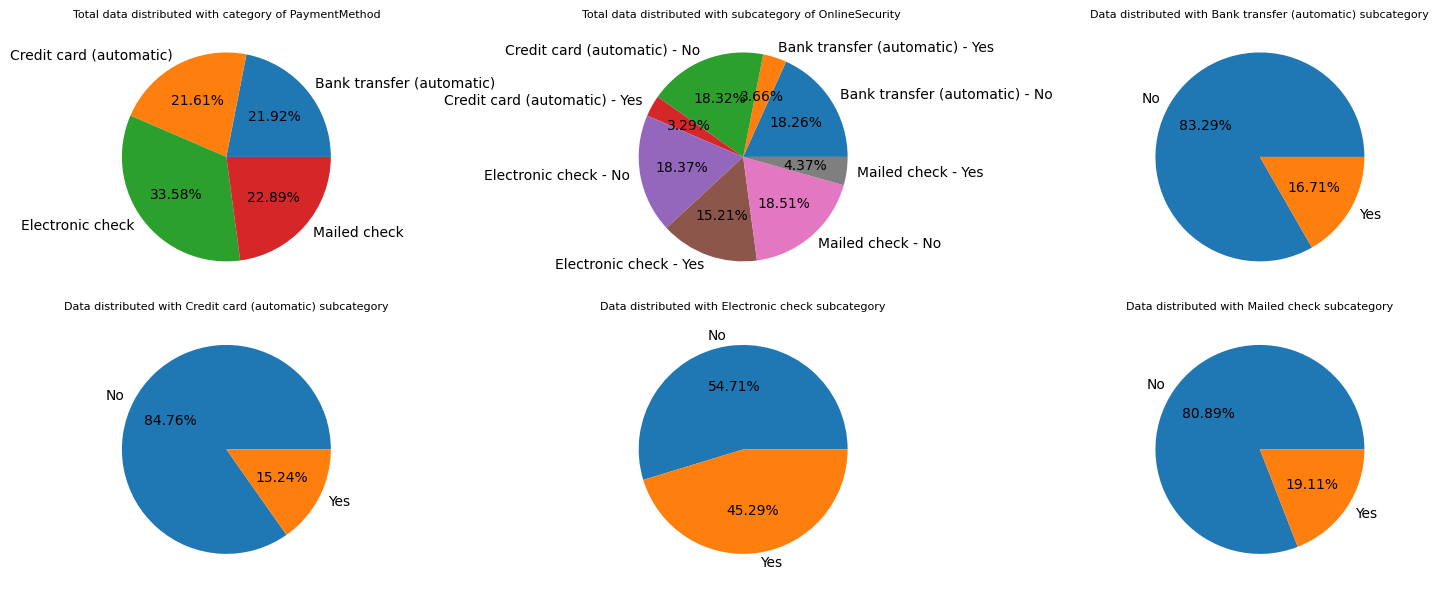

In [18]:
#figure
plt.figure(figsize=(14,6))
#category wise data distribute
plt.subplot(2,3,1)
plt.pie(df1['total_count'],labels=df1['PaymentMethod'],autopct='%1.2f%%')
plt.title(f'Total data distributed with category of PaymentMethod',fontsize=8)

#plot subcategory wise data distribution
plt.subplot(2,3,2)
plt.pie(df2['total_count'],labels=df2['PaymentMethod'] + " - " + df2['Churn'],autopct='%1.2f%%')
plt.title(f"Total data distributed with subcategory of {i} ",fontsize=8)

#plot one of subcategory data distribution
plt.subplot(2,3,3)
plt.pie(df3['total_count'],labels= df3['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df3.iloc[0,0] } subcategory",fontsize=8)

#plot one of subcategory data distribution
plt.subplot(2,3,4)
plt.pie(df4['total_count'],labels= df4['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df4.iloc[0,0] } subcategory",fontsize=8) 

#plot one of subcategory data distribution
plt.subplot(2,3,5)
plt.pie(df5['total_count'],labels= df5['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df5.iloc[0,0] } subcategory",fontsize=8)

#plot one of subcategory data distribution
plt.subplot(2,3,6)
plt.pie(df6['total_count'],labels= df6['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df6.iloc[0,0] } subcategory",fontsize=8)
plt.tight_layout()

plt.show()

##### Insight>>>

In [19]:
print('Insight:\n')
print("Total data distributed of PaymentMethod by subcategory have max and min value for 'Electronic check','credit card (automatic)'\n")
print("Payment method subcategory has highest and lowest churn is 'Electronic check','Credit card (automatic)'")

Insight:

Total data distributed of PaymentMethod by subcategory have max and min value for 'Electronic check','credit card (automatic)'

Payment method subcategory has highest and lowest churn is 'Electronic check','Credit card (automatic)'


#### 5) Analysis of top and bottom 5 total Customer by tenure ?
#### 6) Analysis of top and bottom 5 tenure where highest and lowest churn of customer ?

In [20]:
#checking top and bottom 5 total customer by tenure
top_5=df.groupby('tenure').size().reset_index().rename(columns={0:'total_count'}).sort_values(['total_count']).tail(5)
bottom_5=df.groupby('tenure').size().reset_index().rename(columns={0:'total_count'}).sort_values(['total_count']).head(5)



#checking percentage of Top and Bottom 5 churn of customer by tenure
a=df.groupby(['tenure','Churn']).size().reset_index().rename({0:'total_count'},axis=1)
pivot = a.pivot(index='tenure', columns='Churn', values='total_count').fillna(0)
pivot['perc_churn']=round((pivot['Yes']/(pivot['Yes']+pivot['No']))*100,2)
lowest_churn_perc=pivot.sort_values('perc_churn').head(5)
highest_churn_perc=pivot.sort_values('perc_churn').tail(5)

print('Top 5 customer by tenure :\n')
print(top_5)
print('Bottom 5 customer by tenure :\n')
print(bottom_5)

print('Top 5 customer churn by percentage :\n')
print(lowest_churn_perc)
print('Bottom 5 customer churn by percentage :\n')
print(highest_churn_perc)


Top 5 customer by tenure :

    tenure  total_count
4        4          176
3        3          200
2        2          238
72      72          362
1        1          613
Bottom 5 customer by tenure :

    tenure  total_count
0        0           11
36      36           50
44      44           51
39      39           56
28      28           57
Top 5 customer churn by percentage :

Churn      No  Yes  perc_churn
tenure                        
0        11.0  0.0        0.00
72      356.0  6.0        1.66
71      164.0  6.0        3.53
64       76.0  4.0        5.00
63       68.0  4.0        5.56
Bottom 5 customer churn by percentage :

Churn      No    Yes  perc_churn
tenure                          
3       106.0   94.0       47.00
4        93.0   83.0       47.16
5        69.0   64.0       48.12
2       115.0  123.0       51.68
1       233.0  380.0       61.99


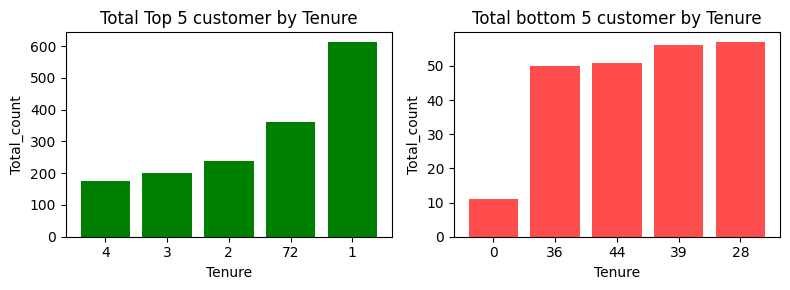

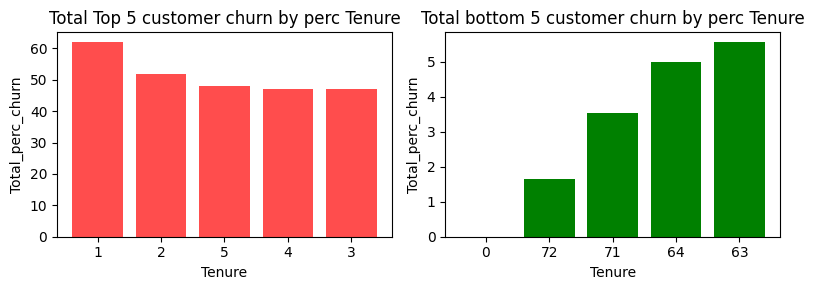

In [21]:
#visualise by graph
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.bar(top_5['tenure'].astype(str),top_5['total_count'],color='green')
plt.title('Total Top 5 customer by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_count')

plt.subplot(1,2,2)
plt.bar(bottom_5['tenure'].astype(str),bottom_5['total_count'],color='#ff4d4d')
plt.title('Total bottom 5 customer by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_count')

plt.tight_layout()
plt.show()

#visualise by graph
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.bar(highest_churn_perc[::-1].index.astype(str),highest_churn_perc[::-1]['perc_churn'],color='#ff4d4d')
plt.title('Total Top 5 customer churn by perc Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_perc_churn')

plt.subplot(1,2,2)
plt.bar(lowest_churn_perc.index.astype(str),lowest_churn_perc['perc_churn'],color='green')
plt.title('Total bottom 5 customer churn by perc Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_perc_churn')

plt.tight_layout()
plt.show()


##### Insight >>>

In [22]:
print("Insight :\n")
print('There is showing top 5 and bottom 5 customer by tenure in first chart')
print('There is showing top 5 and bottom 5 customer by percentage of churn in second chart')

Insight :

There is showing top 5 and bottom 5 customer by tenure in first chart
There is showing top 5 and bottom 5 customer by percentage of churn in second chart


#### 7) Analysis of the Effect of 'MonthlyCharges' and 'TotalCharges' on Customer Churn?
#### 8) Analysis of the Total Customer of 'MonthlyCharges' and 'TotalCharges' ?

In [23]:
#calculating total customer belong to range
for value,i in enumerate(['MonthlyCharges','TotalCharges']):
    print(f'for {i} :\n')
    table = pd.cut(df[i], bins=12).value_counts().sort_index().reset_index()
    table.columns = ['Charges_range', 'count']
    print(f'Data distributed by {i} and calculate total no of customer belong to that range :\n')
    print(table)

#calculating perc of churn by monthly and totalcharges subcategory
for i in ['MonthlyCharges','TotalCharges']:
    #create bins
    bins = pd.cut(df[i], bins=12)
    #create table
    table = df.groupby(bins)['Churn'].value_counts().unstack()
    table['perc_churn']=round((table['Yes']/(table['Yes']+table['No']))*100,2)
    print(f'\npercent of customer churn by {i} :')
    print(table.sort_values('perc_churn'))    

for MonthlyCharges :

Data distributed by MonthlyCharges and calculate total no of customer belong to that range :

        Charges_range  count
0     (18.15, 26.625]   1604
1      (26.625, 35.0]    131
2      (35.0, 43.375]    164
3     (43.375, 51.75]    552
4     (51.75, 60.125]    474
5      (60.125, 68.5]    351
6      (68.5, 76.875]    832
7     (76.875, 85.25]    782
8     (85.25, 93.625]    676
9     (93.625, 102.0]    752
10   (102.0, 110.375]    528
11  (110.375, 118.75]    197
for TotalCharges :

Data distributed by TotalCharges and calculate total no of customer belong to that range :

           Charges_range  count
0      (10.134, 740.967]   2466
1    (740.967, 1463.133]   1166
2     (1463.133, 2185.3]    684
3     (2185.3, 2907.467]    473
4   (2907.467, 3629.633]    415
5     (3629.633, 4351.8]    377
6     (4351.8, 5073.967]    368
7   (5073.967, 5796.133]    311
8     (5796.133, 6518.3]    291
9     (6518.3, 7240.467]    230
10  (7240.467, 7962.633]    174
11    (7962

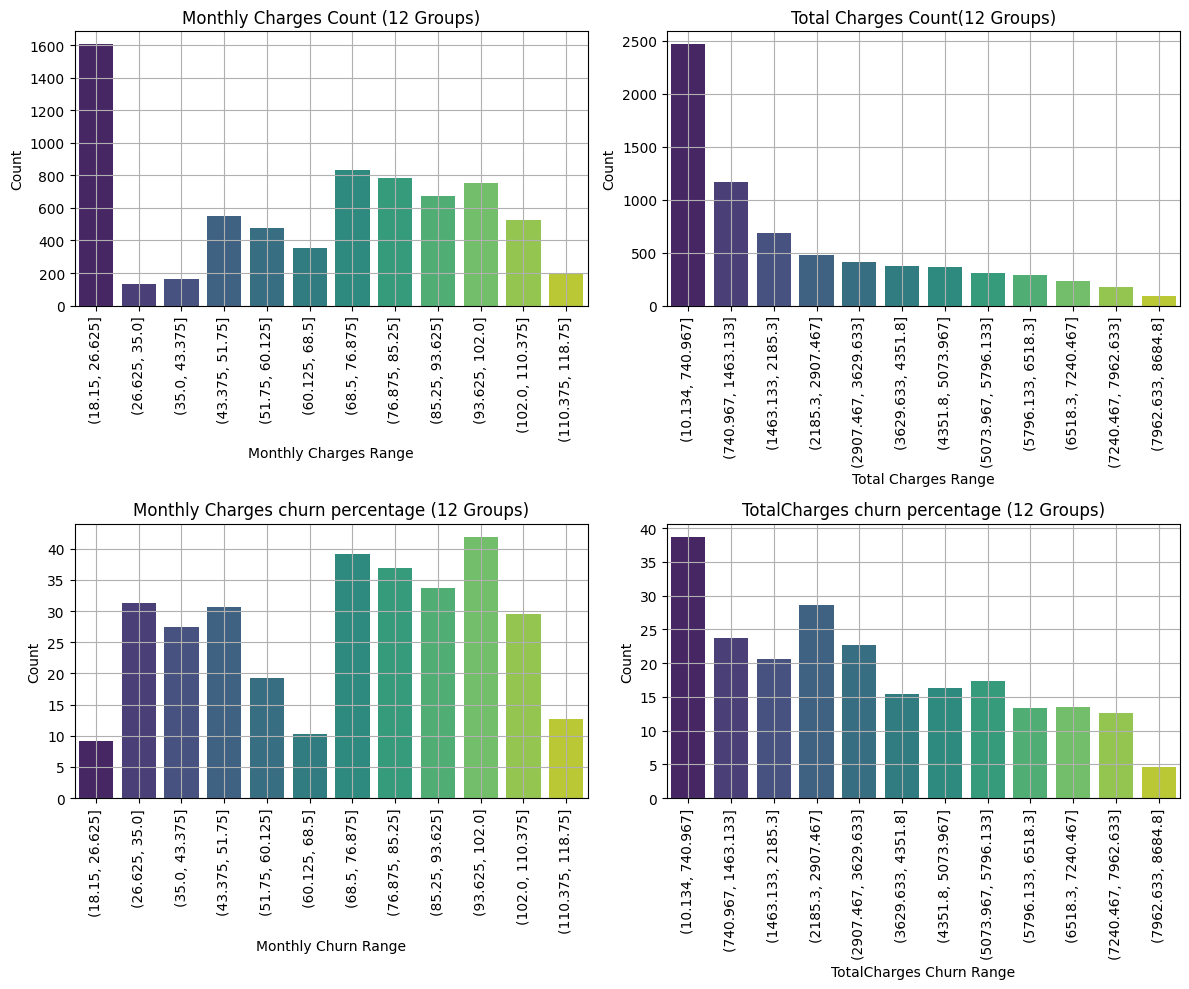

In [24]:
#visualise data 
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
table = pd.cut(df['MonthlyCharges'], bins=12).value_counts().reset_index().sort_values('count')
table.columns = ['MonthlyCharges_range', 'count']
sns.barplot(x=table['MonthlyCharges_range'], y=table['count'],palette='viridis')  #Seaborn barplot() does not automatically keep the order of your DataFrame rows.
plt.xlabel("Monthly Charges Range")
plt.ylabel("Count")
plt.title("Monthly Charges Count (12 Groups)")
plt.grid(True) 
plt.xticks(rotation=90)


plt.subplot(2,2,2)
table = pd.cut(df['TotalCharges'], bins=12).value_counts().sort_values().reset_index()
table.columns = ['TotalCharges_range', 'count']
sns.barplot(x=table['TotalCharges_range'], y=table['count'],palette='viridis')
plt.xlabel("Total Charges Range")
plt.ylabel("Count")
plt.title("Total Charges Count(12 Groups)")
plt.grid(True)
plt.xticks(rotation=90) 


#checking data by monthly and total charges by customer churn ratio

plt.subplot(2,2,3)
bins = pd.cut(df['MonthlyCharges'], bins=12)
table = df.groupby(bins)['Churn'].value_counts().unstack()
table['perc_churn']=round((table['Yes']/(table['Yes']+table['No']))*100,2)
table=table.sort_values('perc_churn')
table

sns.barplot(x=table.index, y=table.perc_churn,palette='viridis')  #Seaborn barplot() does not automatically keep the order of your DataFrame rows.
plt.xlabel("Monthly Churn Range")
plt.ylabel("Count")
plt.title("Monthly Charges churn percentage (12 Groups)")
plt.grid(True) 
plt.xticks(rotation=90)

plt.subplot(2,2,4)
bins = pd.cut(df['TotalCharges'], bins=12)
table = df.groupby(bins)['Churn'].value_counts().unstack()
table['perc_churn']=round((table['Yes']/(table['Yes']+table['No']))*100,2)
table=table.sort_values('perc_churn')

sns.barplot(x=table.index, y=table.perc_churn,palette='viridis')  #Seaborn barplot() does not automatically keep the order of your DataFrame rows.
plt.xlabel("TotalCharges Churn Range")
plt.ylabel("Count")
plt.title("TotalCharges churn percentage (12 Groups)")
plt.grid(True) 
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

##### Insight>>>

In [25]:
print("Insight :\n")

print("MonthlyCharges 18.15-26.625 has highest no of customer and there is lowest percetage of customer churn\n")
print("TotalCharges 10.134-740.967 has highest no of customer and there is also highest percentage of customer churn ")


Insight :

MonthlyCharges 18.15-26.625 has highest no of customer and there is lowest percetage of customer churn

TotalCharges 10.134-740.967 has highest no of customer and there is also highest percentage of customer churn 


## Feature Engineering :

#### Adjust skewness by transformation:

variable TotalCherges has skewness : ,0.9633155974592842

   log_transform  sqrt_transform  power_transform
0      -0.752664        0.309874        -0.145072

Finally transform data by using power_transformer because of skew near to zero 


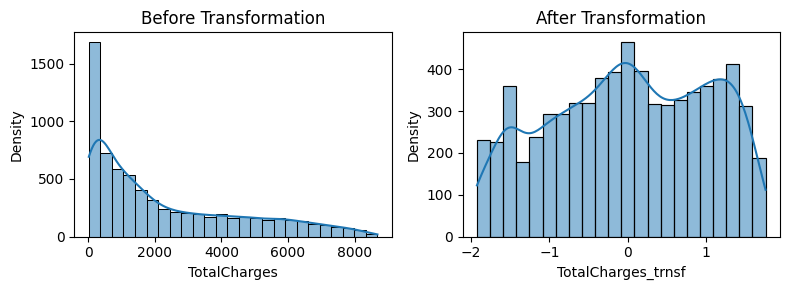

In [26]:
('mean > median ie TotalCharges data skewed toward right\n')
print(f"variable TotalCherges has skewness : ,{df['TotalCharges'].skew()}\n")

#transforming data to adjust skewness 

#log transformer
log_transform=np.log(df['TotalCharges']).skew()
#sqrt transformer
sqrt_transform=np.sqrt(df['TotalCharges']).skew() 
#power transformer
pt=PowerTransformer()
power_transform=pd.DataFrame(pt.fit_transform(df[['TotalCharges']])).skew()[0]

#create dataframe
a=pd.DataFrame({'log_transform':log_transform,
             'sqrt_transform':sqrt_transform,
             "power_transform":power_transform},index=[0])

print(a)

print('\nFinally transform data by using power_transformer because of skew near to zero ')

df['TotalCharges_trnsf']=pd.DataFrame(pt.fit_transform(df[['TotalCharges']]))       #note: not replacing higher (above95) percentile because all value are real here those customer is longer service taking then they paid more so

#draw data distribution diagram after replacing space by median value
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title("Before Transformation")
sns.histplot(df['TotalCharges'], kde=True)
plt.xlabel('TotalCharges')
plt.ylabel('Density')
plt.subplot(1,2,2)
plt.title("After Transformation")
sns.histplot(df['TotalCharges_trnsf'],kde=True)
plt.xlabel('TotalCharges_trnsf')
plt.ylabel('Density')
plt.tight_layout() 
plt.show()

#drop main columns 
df.drop(columns='TotalCharges',inplace=True)
#rename of columns TotalCharges_trnsf to TotalCharges
df.rename(columns={'TotalCharges_trnsf':'TotalCharges'},inplace=True)

#### To transform categorical data (str) to int :

To transform categorical data (str) to int type there are too many method like 
* OneHotEncoding,
* LabelEncoding,
* Map method ,
* pd.get_dummies
  
but for practice i use all 

In [27]:
#map

#use map method to change 'yes'>1 and 'No'>0 'No internet service' >2
#2-category
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['gender']=df['gender'].map({'Male':1,'Female':0})
df['Partner']=df['Partner'].map({'Yes':1,'No':0})
df['Dependents']=df['Dependents'].map({'Yes':1,'No':0})
#3-category
df['MultipleLines']=df['MultipleLines'].map({'Yes':1,'No':0,'No phone service':2})
df['TechSupport']=df['TechSupport'].map({'Yes':1,'No':0,'No internet service':2})
df['OnlineSecurity']=df['OnlineSecurity'].map({'Yes':1,'No':0,'No internet service':2})
df['OnlineBackup']=df['OnlineBackup'].map({'Yes':1,'No':0,'No internet service':2})
df['DeviceProtection']=df['DeviceProtection'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingTV']=df['StreamingTV'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingMovies']=df['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':2})


#LabelEncoder 

le=LabelEncoder()
cols = ['PhoneService', 'PaperlessBilling']

for col in cols:
    df[col] = le.fit_transform(df[col])

#get dummies

a=pd.get_dummies(df['PaymentMethod'],dtype=int,prefix='PaymentMethod')
#added in main dataframe
df=pd.concat([df,a],axis=1)
df.drop(columns='PaymentMethod',inplace=True)    #droping main columns

#OneHotEncoder

oe=OneHotEncoder(sparse_output=False,feature_name_combiner='concat',dtype=int)
encoded= oe.fit_transform(df[['InternetService','Contract']])

df.drop(columns=['InternetService','Contract'],inplace=True)   #drop original

cols=oe.get_feature_names_out()
df=pd.concat([df,pd.DataFrame(encoded, columns=cols)],axis=1)


#### Checking correlation of variables :

Correlation Map :



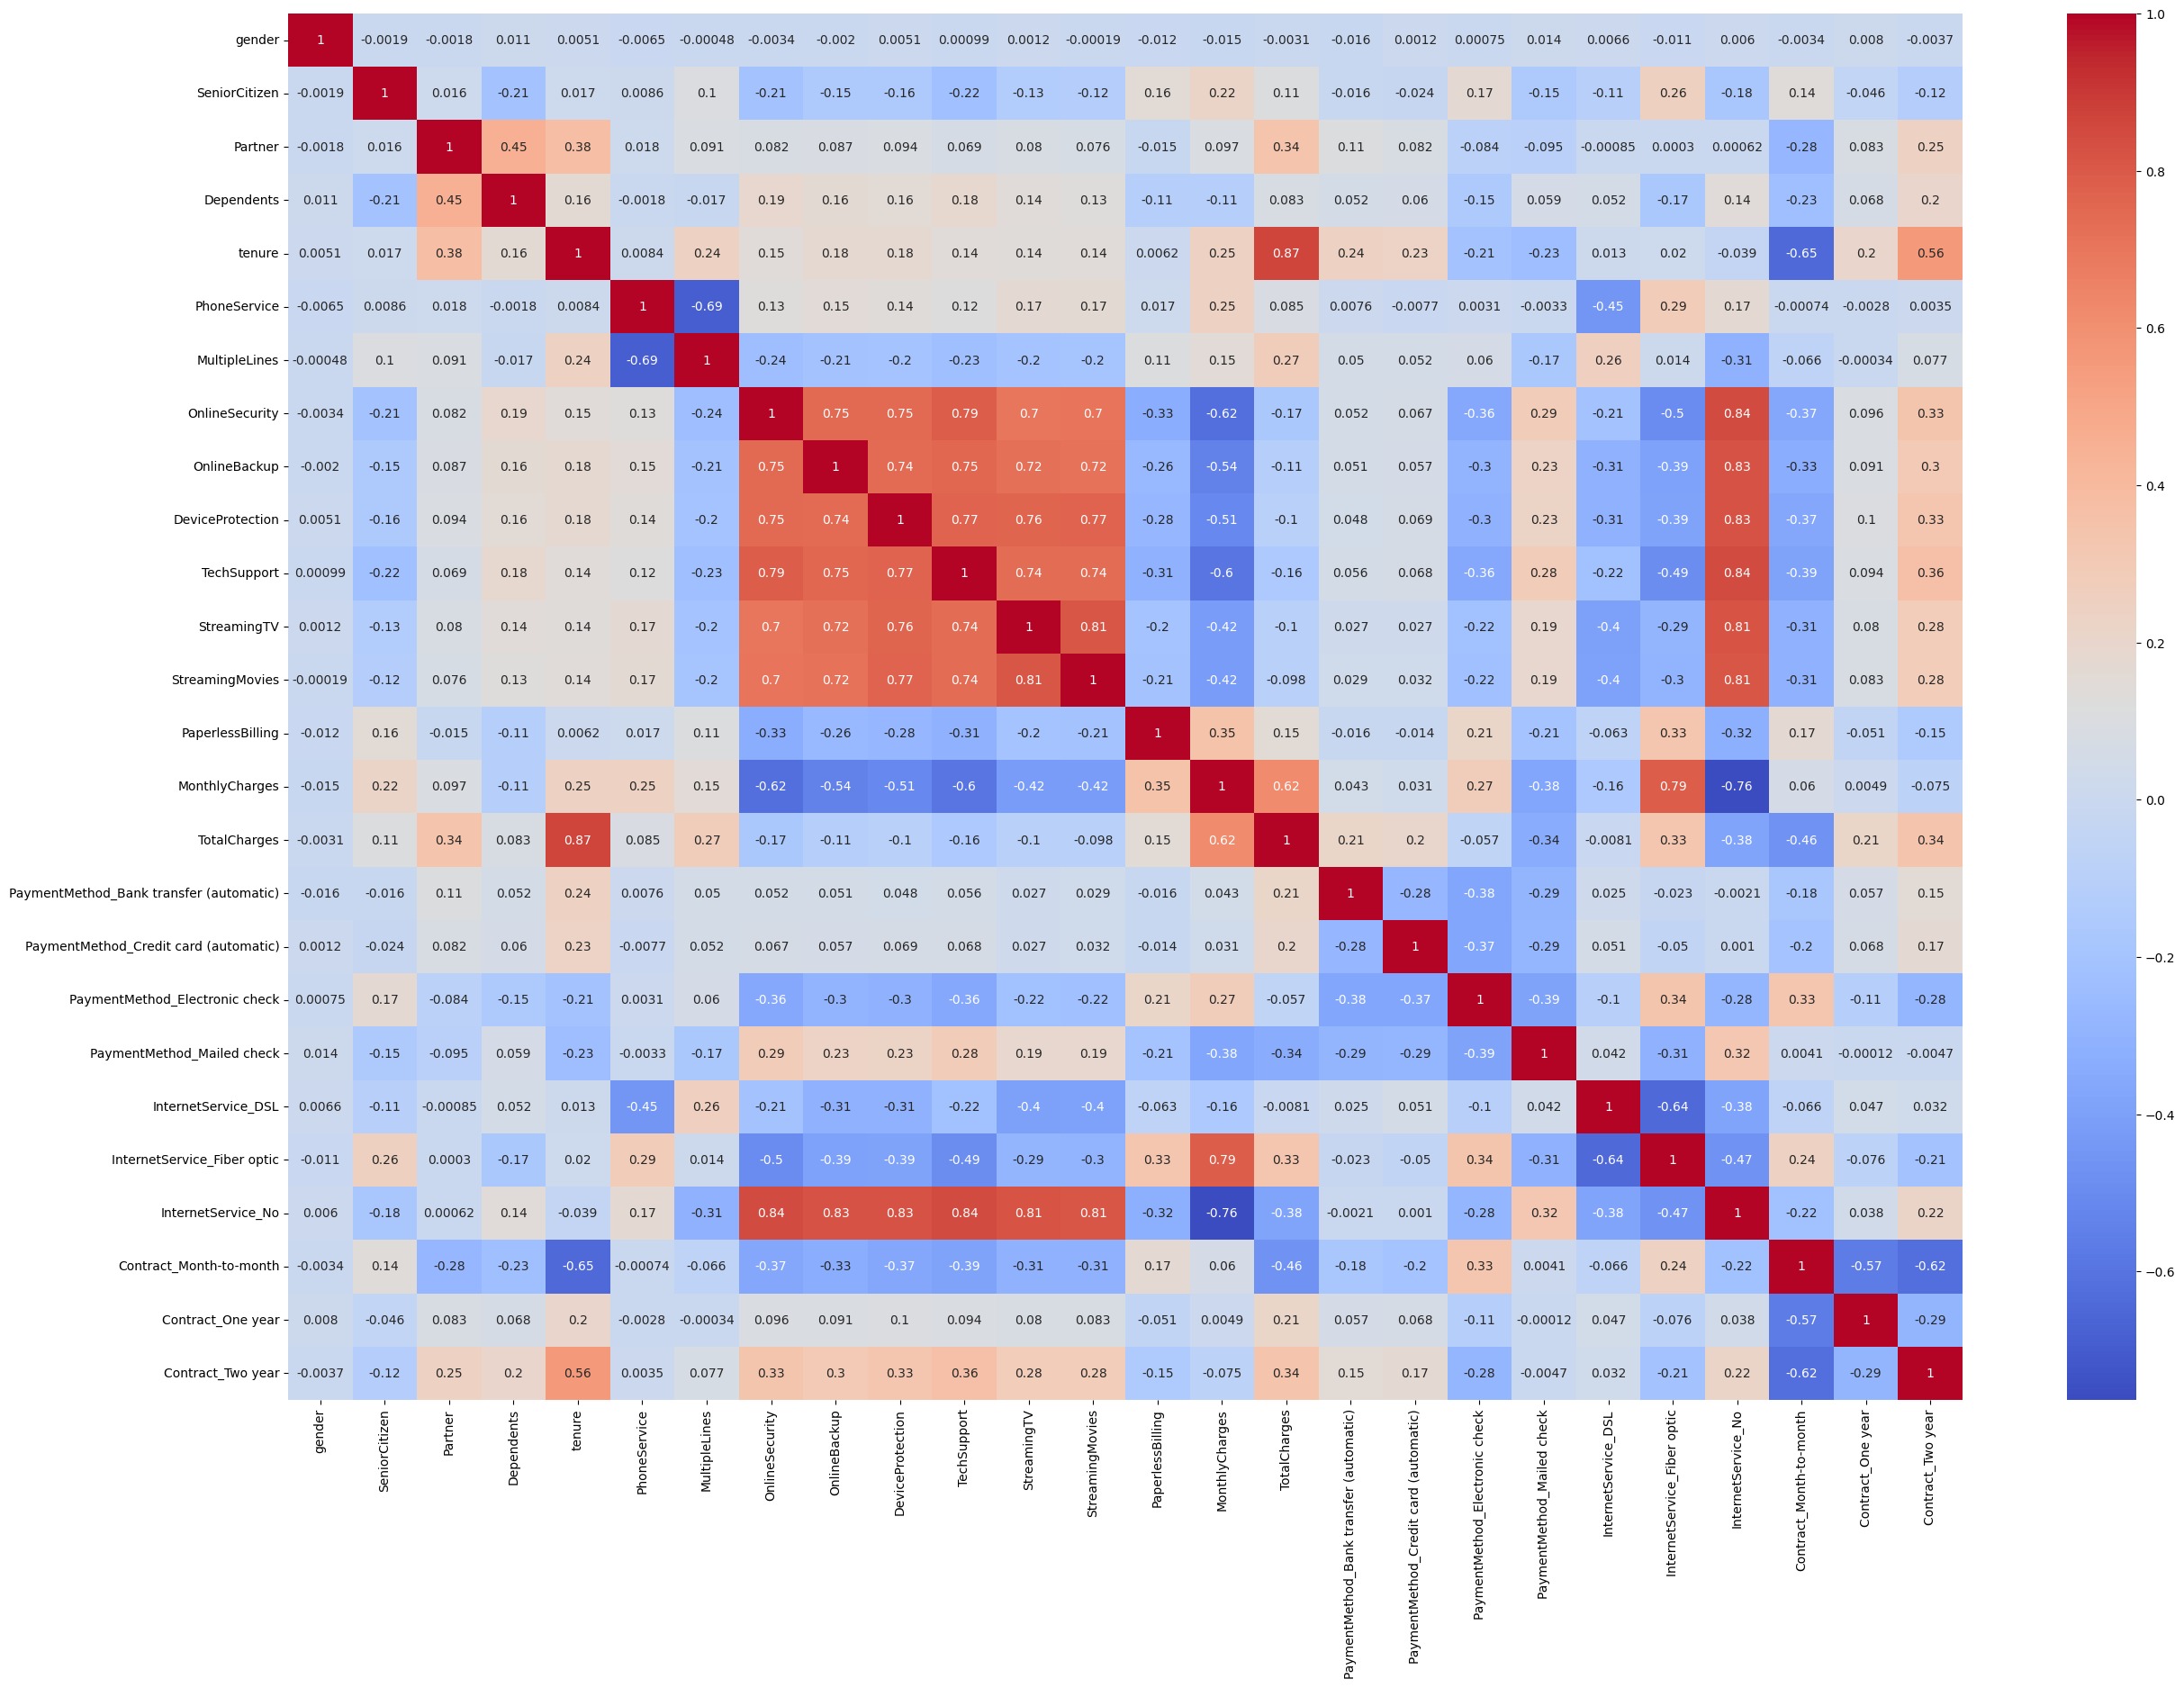

In [31]:
#checking correlation  of each features
print("Correlation Map :\n")
plt.figure(figsize=(30,20))
sns.heatmap(df.drop(['Churn','customerID'],axis=1).corr(),annot=True,cmap='coolwarm')
plt.show()


#### Feature Selection (by VIF method) : 

In [47]:

#create function to calculate vif
def calc_vif(X):
"""It calculate vif of input data"""
# Calculating VIF
    vif= pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

"VIF = 1 → no multicollinearity
VIF > 5 → moderate problem
VIF > 10 → serious multicollinearity  " 


print(calc_vif(df[[i for i in df.describe().columns if i not in ['customerID','Churn','PaymentMethod_Bank transfer (automatic)',
                                                                 'InternetService_DSL','InternetService_No', 'Contract_Month-to-month',
                                                               'PhoneService' ]]]))


                                variables        VIF
0                                  gender   1.998899
1                           SeniorCitizen   1.372580
2                                 Partner   2.824818
3                              Dependents   1.967906
4                                  tenure  17.096037
5                           MultipleLines   2.213203
6                          OnlineSecurity   6.906317
7                            OnlineBackup   6.550403
8                        DeviceProtection   7.386521
9                             TechSupport   7.628111
10                            StreamingTV   8.021208
11                        StreamingMovies   8.081835
12                       PaperlessBilling   2.936625
13                         MonthlyCharges  14.954595
14                           TotalCharges   5.003720
15  PaymentMethod_Credit card (automatic)   1.941283
16         PaymentMethod_Electronic check   2.891873
17             PaymentMethod_Mailed check   2.

#### New feature creating:

In [50]:
def cal_MonthlyCharges(X):
    "This function return category of MonthlyCharges"
    if X<=30:
        return 0
    elif X>30 and X<=60:
        return 1
    elif X>60 and X<=90:
        return 2
    else:
        return 3

df['MonthlyCharges_category']=df['MonthlyCharges'].apply(cal_MonthlyCharges)

#### Data Class Balancing (SMOTE) :

In [56]:
print('Checking churn data diff class total :\n',
     df['Churn'].value_counts())

Checking churn data diff class total :
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [65]:
# count diff class total 
print("Checking data distributed with different classes :")
print(df['Churn'].value_counts().reset_index())
print("\nData is imbalanced here so use SMOTE technique to balance data :\n")



from imblearn.over_sampling import SMOTE

X = df.drop(['Churn','customerID'],axis=1)
y = df['Churn']

smote = SMOTE(sampling_strategy={1:4000}, random_state=5)  #partial oversampling data 

X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"Before smote technique shape of real data is : {X.shape}")
print(f"After smote technique shape of resampled data is : {X_resampled.shape}")
print("and shape",y_resampled.value_counts())

Checking data distributed with different classes :
   Churn  count
0      0   5174
1      1   1869

Data is imbalanced here so use SMOTE technique to balance data :

Before smote technique shape of real data is : (7043, 27)
After smote technique shape of resampled data is : (9174, 27)
and shape Churn
0    5174
1    4000
Name: count, dtype: int64


#### Final transform data view :

In [66]:
##final data review
X_resampled.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,MonthlyCharges_category
0,0,0,1,0,1,0,2,0,1,0,0,0,0,1,29.85,-1.805206,0,0,1,0,1,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,0.256861,0,0,0,1,1,0,0,0,1,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,-1.381338,0,0,0,1,1,0,0,1,0,0,1
3,1,0,0,0,45,0,2,1,0,1,1,0,0,0,42.30,0.235865,1,0,0,0,1,0,0,0,1,0,1
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,-1.244141,0,0,1,0,0,1,0,1,0,0,2


In [70]:
y_resampled.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## ML model Fittings